<a href="https://colab.research.google.com/github/Ankitharrao/CakeWEB/blob/main/Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== 1. MOUNT DRIVE =====
from google.colab import drive
drive.mount('/content/drive')

# ===== 2. IMPORTS =====
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ===== 3. LOAD FINAL CLEAN DATASET =====
final_clean_df = pd.read_csv('/content/drive/MyDrive/crop_yield_project/karnataka_final_clean_dataset.csv')
print("Loaded:", final_clean_df.shape)

# ===== 4. FILTER TO RICE =====
crop_df = final_clean_df[final_clean_df['Crop'] == 'Rice'].copy()

# ===== 5. REMOVE NEAR-ZERO (FAILURE) YIELD ROWS =====
crop_df_clean = crop_df[crop_df['yield'] >= 10].copy()
print("Rice, non-failure:", crop_df_clean.shape)

# ===== 6. LOG-TRANSFORM TARGET =====
crop_df_clean['yield_log'] = np.log1p(crop_df_clean['yield'])

# ===== 7. BUILD SEQUENCE ARRAY (weather + NDVI) =====
variables = ['rainfall', 'temp_avg', 'temp_max', 'temp_min', 'humidity', 'ndvi']
months = list(range(1, 13))

sequences = []
for var in variables:
    cols = [f"{var}_{m}" for m in months]
    sequences.append(crop_df_clean[cols].values)

X_sequence_clean = np.stack(sequences, axis=-1)

# ===== 8. BUILD STATIC FEATURES (District + Season) =====
static_features = pd.get_dummies(crop_df_clean[['District_Name', 'Season']], drop_first=True)

# ===== 9. TARGET =====
y_clean = crop_df_clean['yield_log'].values

# ===== 10. TRAIN/TEST SPLIT BY YEAR =====rr
train_mask = crop_df_clean['Crop_Year'] <= 2015
test_mask = crop_df_clean['Crop_Year'] > 2015

X_train_clean, X_test_clean = X_sequence_clean[train_mask], X_sequence_clean[test_mask]
X_train_static, X_test_static = static_features[train_mask].values, static_features[test_mask].values
y_train_clean, y_test_clean = y_clean[train_mask], y_clean[test_mask]

print("Sequence - Train:", X_train_clean.shape, "Test:", X_test_clean.shape)
print("Static - Train:", X_train_static.shape, "Test:", X_test_static.shape)

# ===== 11. SCALE SEQUENCE FEATURES =====
n_samples, n_timesteps, n_features = X_train_clean.shape
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean.reshape(-1, n_features)).reshape(n_samples, n_timesteps, n_features)
X_test_clean_scaled = scaler_clean.transform(X_test_clean.reshape(-1, n_features)).reshape(X_test_clean.shape[0], n_timesteps, n_features)

print("Setup complete — ready for model building.")

Mounted at /content/drive
Loaded: (28928, 80)
Rice, non-failure: (907, 80)
Sequence - Train: (662, 12, 6) Test: (245, 12, 6)
Static - Train: (662, 28) Test: (245, 28)
Setup complete — ready for model building.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate

# Branch 1: sequence input (weather + NDVI)
sequence_input = Input(shape=(12, 6), name='sequence_input')
lstm_out = LSTM(32)(sequence_input)
lstm_out = Dropout(0.3)(lstm_out)

# Branch 2: static input (District + Season)
static_input = Input(shape=(X_train_static.shape[1],), name='static_input')
static_out = Dense(16, activation='relu')(static_input)

# Merge both branches
merged = Concatenate()([lstm_out, static_out])
merged = Dense(16, activation='relu')(merged)
output = Dense(1)(merged)

model_combined = Model(inputs=[sequence_input, static_input], outputs=output)
model_combined.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_combined.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 12, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,992 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 28)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        464 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        784 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,257 (24.44 KB)

 Trainable params: 6,257 (24.44 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_combined = model_combined.fit(
    [X_train_clean_scaled, X_train_static], y_train_clean,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 19.3453 - mae: 4.2889 - val_loss: 6.5445 - val_mae: 2.4424
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.4172 - mae: 1.2169 - val_loss: 0.4000 - val_mae: 0.5097
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9564 - mae: 0.7817 - val_loss: 0.2403 - val_mae: 0.3956
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7934 - mae: 0.7038 - val_loss: 0.1954 - val_mae: 0.3598
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6673 - mae: 0.6628 - val_loss: 0.1526 - val_mae: 0.3173
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6372 - mae: 0.6351 - val_loss: 0.1213 - val_mae: 0.2815
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5561 - mae: 0.5983 - val_loss: 0.1020 - val_mae: 0.2583
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5079 - mae: 0.5597 - val_loss: 0.0891 - val_mae: 0.2433
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4

In [ ]:
model_combined.save('/content/drive/MyDrive/crop_yield_project/lstm_model_combined.keras')

import joblib
joblib.dump(scaler_clean, '/content/drive/MyDrive/crop_yield_project/scaler_combined.pkl')

['/content/drive/MyDrive/crop_yield_project/scaler_combined.pkl']

In [ ]:
test_loss, test_mae = model_combined.evaluate([X_test_clean_scaled, X_test_static], y_test_clean)
print(f"Test Loss (MSE): {test_loss}")
print(f"Test MAE: {test_mae}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0925 - mae: 0.2125 
Test Loss (MSE): 0.0925029069185257
Test MAE: 0.21249864995479584


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y_pred_log = model_combined.predict([X_test_clean_scaled, X_test_static]).flatten()
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_clean)

mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"RMSE (real yield scale): {rmse}")
print(f"R²: {r2}")

# Compare against naive baseline again
naive_pred = np.full_like(y_test_actual, np.expm1(y_train_clean.mean()))
naive_rmse = np.sqrt(mean_squared_error(y_test_actual, naive_pred))
print(f"Naive baseline RMSE: {naive_rmse}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
RMSE (real yield scale): 69.88067613767275
R²: -0.011758174433835977
Naive baseline RMSE: 74.16973975801129


In [ ]:
crop_counts = final_clean_df['Crop'].value_counts()
selected_crops = crop_counts[crop_counts >= 500].index.tolist()
print(selected_crops)
print(len(selected_crops))

['Maize', 'Sunflower', 'Rice', 'Dry chillies', 'Onion', 'Jowar', 'Groundnut', 'Horse-gram', 'Ragi', 'Moong(Green Gram)', 'Urad', 'Potato', 'Cowpea(Lobia)', 'Cotton(lint)', 'Gram', 'Coconut', 'Arhar/Tur', 'Sesamum', 'Other Kharif pulses', 'Bajra', 'Niger seed', 'Sugarcane', 'Coriander', 'Castor seed']
24


In [ ]:
multi_crop_df = final_clean_df[final_clean_df['Crop'].isin(selected_crops)].copy()
print(multi_crop_df.shape)

(22250, 80)


In [ ]:
def flag_failures(group):
    threshold = group['yield'].quantile(0.1)  # bottom 10% within each crop
    return group['yield'] > threshold

multi_crop_df = multi_crop_df.groupby('Crop', group_keys=False).apply(
    lambda g: g[g['yield'] > g['yield'].quantile(0.1)]
)
print(multi_crop_df.shape)

(20009, 80)


/tmp/ipykernel_1631/2265030653.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  multi_crop_df = multi_crop_df.groupby('Crop', group_keys=False).apply(


In [ ]:
multi_crop_df['yield_zscore'] = multi_crop_df.groupby('Crop')['yield'].transform(
    lambda x: (x - x.mean()) / x.std()
)
print(multi_crop_df['yield_zscore'].describe())

count    2.000900e+04
mean    -5.681785e-18
std      9.994251e-01
min     -1.357606e+00
25%     -1.024575e+00
50%      5.737842e-02
75%      7.178966e-01
max      1.522065e+01
Name: yield_zscore, dtype: float64


In [ ]:
variables = ['rainfall', 'temp_avg', 'temp_max', 'temp_min', 'humidity', 'ndvi']
months = list(range(1, 13))

sequences = []
for var in variables:
    cols = [f"{var}_{m}" for m in months]
    sequences.append(multi_crop_df[cols].values)

X_sequence_multi = np.stack(sequences, axis=-1)
print(X_sequence_multi.shape)

(20009, 12, 6)


In [ ]:
static_features_multi = pd.get_dummies(multi_crop_df[['District_Name', 'Season', 'Crop']], drop_first=True)
print(static_features_multi.shape)

(20009, 52)


In [ ]:
y_multi = multi_crop_df['yield_zscore'].values

train_mask = multi_crop_df['Crop_Year'] <= 2015
test_mask = multi_crop_df['Crop_Year'] > 2015

X_train_multi, X_test_multi = X_sequence_multi[train_mask], X_sequence_multi[test_mask]
X_train_static_multi, X_test_static_multi = static_features_multi[train_mask].values, static_features_multi[test_mask].values
y_train_multi, y_test_multi = y_multi[train_mask], y_multi[test_mask]

print("Sequence - Train:", X_train_multi.shape, "Test:", X_test_multi.shape)
print("Static - Train:", X_train_static_multi.shape, "Test:", X_test_static_multi.shape)

Sequence - Train: (16287, 12, 6) Test: (3722, 12, 6)
Static - Train: (16287, 52) Test: (3722, 52)


In [ ]:
n_samples, n_timesteps, n_features = X_train_multi.shape
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi.reshape(-1, n_features)).reshape(n_samples, n_timesteps, n_features)
X_test_multi_scaled = scaler_multi.transform(X_test_multi.reshape(-1, n_features)).reshape(X_test_multi.shape[0], n_timesteps, n_features)

print("Scaling done.")

Scaling done.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate

sequence_input = Input(shape=(12, 6), name='sequence_input')
lstm_out = LSTM(64)(sequence_input)
lstm_out = Dropout(0.3)(lstm_out)

static_input = Input(shape=(X_train_static_multi.shape[1],), name='static_input')
static_out = Dense(32, activation='relu')(static_input)
static_out = Dropout(0.2)(static_out)

merged = Concatenate()([lstm_out, static_out])
merged = Dense(32, activation='relu')(merged)
merged = Dropout(0.2)(merged)
output = Dense(1)(merged)

model_multi = Model(inputs=[sequence_input, static_input], outputs=output)
model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_multi.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 12, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     18,176 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,696 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      3,104 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,009 (89.88 KB)

 Trainable params: 23,009 (89.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_multi = model_multi.fit(
    [X_train_multi_scaled, X_train_static_multi], y_train_multi,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.9411 - mae: 0.8354 - val_loss: 0.9193 - val_mae: 0.7760
Epoch 2/50
 30/459 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9505 - mae: 0.8342

KeyboardInterrupt: 

In [ ]:
history_multi = model_multi.fit(
    [X_train_multi_scaled, X_train_static_multi], y_train_multi,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.9306 - mae: 0.8306 - val_loss: 0.9703 - val_mae: 0.7968
Epoch 2/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9241 - mae: 0.8266 - val_loss: 0.9858 - val_mae: 0.8001
Epoch 3/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9161 - mae: 0.8230 - val_loss: 1.1676 - val_mae: 0.8464
Epoch 4/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.9100 - mae: 0.8204 - val_loss: 1.3328 - val_mae: 0.8810
Epoch 5/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.9086 - mae: 0.8199 - val_loss: 1.2042 - val_mae: 0.8550
Epoch 6/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.9069 - mae: 0.8197 - val_loss: 1.2417 - val_mae: 0.8624
Epoch 7/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.9028 - mae: 0.8167 - val_loss: 1.2784 - val_mae: 0.8714
Epoch 8/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9027 - mae: 0.8178 - val_loss: 1.2130 - val_mae: 0.8573
Epoch 9/50
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

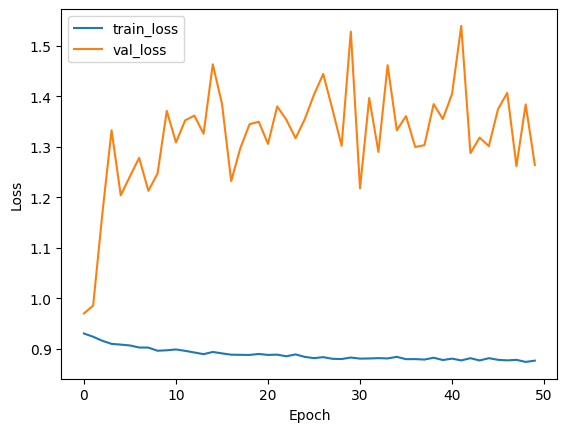

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_multi.history['loss'], label='train_loss')
plt.plot(history_multi.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Rebuild a slightly smaller, more regularized model
sequence_input = Input(shape=(12, 6), name='sequence_input')
lstm_out = LSTM(32)(sequence_input)
lstm_out = Dropout(0.4)(lstm_out)

static_input = Input(shape=(X_train_static_multi.shape[1],), name='static_input')
static_out = Dense(16, activation='relu')(static_input)
static_out = Dropout(0.3)(static_out)

merged = Concatenate()([lstm_out, static_out])
merged = Dense(16, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(1)(merged)

model_multi_v2 = Model(inputs=[sequence_input, static_input], outputs=output)
model_multi_v2.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_multi_v2 = model_multi_v2.fit(
    [X_train_multi_scaled, X_train_static_multi], y_train_multi,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.9469 - mae: 0.8371 - val_loss: 0.8897 - val_mae: 0.7645
Epoch 2/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.9362 - mae: 0.8341 - val_loss: 0.8936 - val_mae: 0.7655
Epoch 3/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9315 - mae: 0.8313 - val_loss: 0.8964 - val_mae: 0.7690
Epoch 4/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.9271 - mae: 0.8292 - val_loss: 0.9259 - val_mae: 0.7818
Epoch 5/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.9240 - mae: 0.8278 - val_loss: 0.9875 - val_mae: 0.8059
Epoch 6/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9204 - mae: 0.8262 - val_loss: 1.0885 - val_mae: 0.8331
Epoch 7/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9154 - mae: 0.8230 - val_loss: 1.1413 - val_mae: 0.8466
Epoch 8/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.9110 - mae: 0.8216 - val_loss: 1.1654 - val_mae: 0.8514
Epoch 9/100
459/459 ━━━━━━━━━━━━━━━━━━━━ 4s 8

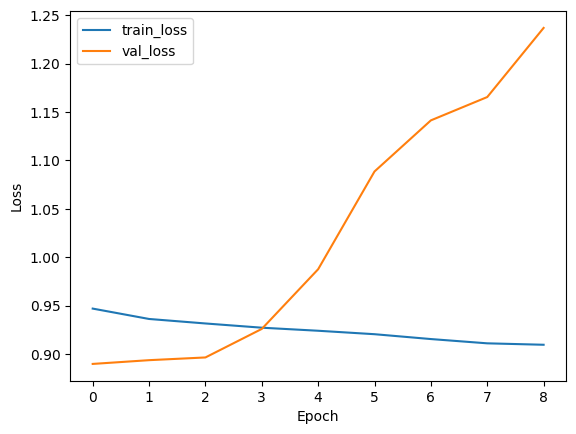

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_multi_v2.history['loss'], label='train_loss')
plt.plot(history_multi_v2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model_multi_v2.save('/content/drive/MyDrive/crop_yield_project/lstm_model_multi_v2.keras')

import joblib
joblib.dump(scaler_multi, '/content/drive/MyDrive/crop_yield_project/scaler_multi.pkl')

['/content/drive/MyDrive/crop_yield_project/scaler_multi.pkl']

In [ ]:
test_loss, test_mae = model_multi_v2.evaluate([X_test_multi_scaled, X_test_static_multi], y_test_multi)
print(f"Test Loss (MSE): {test_loss}")
print(f"Test MAE: {test_mae}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3418 - mae: 0.9051
Test Loss (MSE): 1.3417720794677734
Test MAE: 0.9051108360290527


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model_multi_v2.predict([X_test_multi_scaled, X_test_static_multi]).flatten()

mse = mean_squared_error(y_test_multi, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_multi, y_pred)

print(f"RMSE (z-score scale): {rmse}")
print(f"R²: {r2}")

# Naive baseline comparison
naive_pred = np.full_like(y_test_multi, y_train_multi.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test_multi, naive_pred))
print(f"Naive baseline RMSE: {naive_rmse}")

NameError: name 'model_multi_v2' is not defined

In [ ]:
# ===== 1. MOUNT DRIVE =====
from google.colab import drive
drive.mount('/content/drive')

# ===== 2. IMPORTS =====
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ===== 3. LOAD FINAL CLEAN DATASET =====
final_clean_df = pd.read_csv('/content/drive/MyDrive/crop_yield_project/karnataka_final_clean_dataset.csv')

# ===== 4. FILTER TO RICE, REMOVE FAILURE ROWS =====
crop_df = final_clean_df[final_clean_df['Crop'] == 'Rice'].copy()
crop_df_clean = crop_df[crop_df['yield'] >= 10].copy()
print("Rice, non-failure:", crop_df_clean.shape)

# ===== 5. BUILD FLAT FEATURES FOR RANDOM FOREST =====
feature_cols = [col for col in crop_df_clean.columns if any(
    col.startswith(prefix) for prefix in ['rainfall_', 'temp_avg_', 'temp_max_', 'temp_min_', 'humidity_', 'ndvi_']
)]

X_rf = crop_df_clean[feature_cols].copy()

static_rf = pd.get_dummies(crop_df_clean[['District_Name', 'Season']], drop_first=True)
X_rf = pd.concat([X_rf.reset_index(drop=True), static_rf.reset_index(drop=True)], axis=1)

print("Feature matrix:", X_rf.shape)

# ===== 6. TARGET + TRAIN/TEST SPLIT BY YEAR =====
y_rf = crop_df_clean['yield'].values

train_mask = crop_df_clean['Crop_Year'].values <= 2015
test_mask = crop_df_clean['Crop_Year'].values > 2015

X_train_rf, X_test_rf = X_rf[train_mask], X_rf[test_mask]
y_train_rf, y_test_rf = y_rf[train_mask], y_rf[test_mask]

print("Train:", X_train_rf.shape, "Test:", X_test_rf.shape)

Mounted at /content/drive
Rice, non-failure: (907, 80)
Feature matrix: (907, 100)
Train: (662, 100) Test: (245, 100)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_rf)

mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf}")
print(f"Random Forest R²: {r2_rf}")

# Compare to naive baseline
naive_pred = np.full_like(y_test_rf, y_train_rf.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test_rf, naive_pred))
print(f"Naive baseline RMSE: {naive_rmse}")

Random Forest RMSE: 63.53448002704029
Random Forest R²: 0.16366266408258634
Naive baseline RMSE: 70.37912276284659


In [ ]:
for cutoff in [10, 5, 2, 1, 0.5]:
    remaining = crop_df[crop_df['yield'] >= cutoff]
    print(f"Cutoff {cutoff}: {len(remaining)} rows remain")

Cutoff 10: 907 rows remain
Cutoff 5: 908 rows remain
Cutoff 2: 1403 rows remain
Cutoff 1: 1485 rows remain
Cutoff 0.5: 1506 rows remain


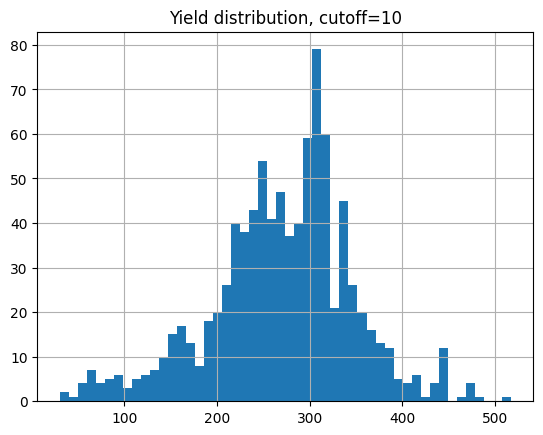

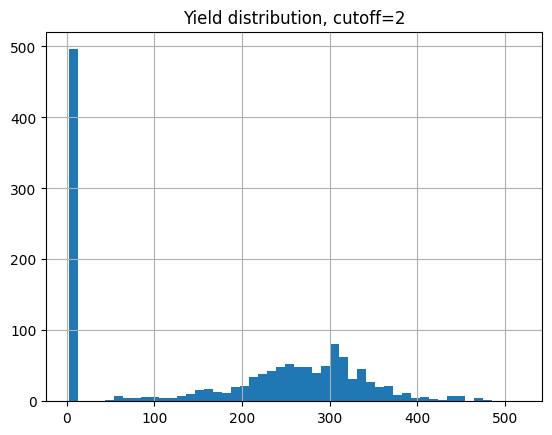

In [ ]:
import matplotlib.pyplot as plt

for cutoff in [10, 2]:
    subset = crop_df[crop_df['yield'] >= cutoff]
    subset['yield'].hist(bins=50)
    plt.title(f'Yield distribution, cutoff={cutoff}')
    plt.show()

In [ ]:
# ===== 1. MOUNT DRIVE =====
from google.colab import drive
drive.mount('/content/drive')

# ===== 2. IMPORTS =====
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ===== 3. LOAD FINAL CLEAN DATASET =====
final_clean_df = pd.read_csv('/content/drive/MyDrive/crop_yield_project/karnataka_final_clean_dataset.csv')

# ===== 4. FILTER TO RICE, REMOVE FAILURE ROWS =====
crop_df = final_clean_df[final_clean_df['Crop'] == 'Rice'].copy()
crop_df_clean = crop_df[crop_df['yield'] >= 10].copy()
print("Rice, non-failure:", crop_df_clean.shape)

# ===== 5. BUILD FLAT FEATURES (same as Random Forest used) =====
feature_cols = [col for col in crop_df_clean.columns if any(
    col.startswith(prefix) for prefix in ['rainfall_', 'temp_avg_', 'temp_max_', 'temp_min_', 'humidity_', 'ndvi_']
)]

X_flat = crop_df_clean[feature_cols].copy()
static_flat = pd.get_dummies(crop_df_clean[['District_Name', 'Season']], drop_first=True)
X_flat = pd.concat([X_flat.reset_index(drop=True), static_flat.reset_index(drop=True)], axis=1)

print("Feature matrix:", X_flat.shape)

# ===== 6. TARGET + TRAIN/TEST SPLIT BY YEAR =====
y_flat = crop_df_clean['yield'].values
train_mask = crop_df_clean['Crop_Year'].values <= 2015
test_mask = crop_df_clean['Crop_Year'].values > 2015

X_train_flat, X_test_flat = X_flat[train_mask], X_flat[test_mask]
y_train_flat, y_test_flat = y_flat[train_mask], y_flat[test_mask]

print("Train:", X_train_flat.shape, "Test:", X_test_flat.shape)

# ===== 7. SCALE FEATURES (ANN needs this, RF didn't) =====
from sklearn.preprocessing import StandardScaler
scaler_ann = StandardScaler()
X_train_flat_scaled = scaler_ann.fit_transform(X_train_flat)
X_test_flat_scaled = scaler_ann.transform(X_test_flat)

print("Setup complete.")

Mounted at /content/drive
Rice, non-failure: (907, 80)
Feature matrix: (907, 100)
Train: (662, 100) Test: (245, 100)
Setup complete.


In [ ]:
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_flat_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
ann_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_ann = ann_model.fit(
    X_train_flat_scaled, y_train_flat,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 77679.1562 - mae: 266.6866 - val_loss: 67650.9141 - val_mae: 253.9857
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70651.7734 - mae: 252.9272 - val_loss: 52147.6250 - val_mae: 220.8484
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 40844.2383 - mae: 180.7230 - val_loss: 15421.5303 - val_mae: 100.0978
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18435.6055 - mae: 113.0024 - val_loss: 9742.1699 - val_mae: 77.7340
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12614.8643 - mae: 91.3175 - val_loss: 6104.8413 - val_mae: 60.5878
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10035.8740 - mae: 80.4295 - val_loss: 4726.4473 - val_mae: 53.9818
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8099.2007 - mae: 72.3036 - val_loss: 3894.0989 - val_mae: 50.0670
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7399.9805 - mae: 68.6252 - val_loss: 3924.7781 

In [ ]:
ann_model.save('/content/drive/MyDrive/crop_yield_project/ann_model_rice.keras')

import joblib
joblib.dump(scaler_ann, '/content/drive/MyDrive/crop_yield_project/scaler_ann.pkl')

['/content/drive/MyDrive/crop_yield_project/scaler_ann.pkl']

In [ ]:
ry_pred_ann = ann_model.predict(X_test_flat_scaled).flatten()

mse_ann = mean_squared_error(y_test_flat, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test_flat, y_pred_ann)
mae_ann = mean_absolute_error(y_test_flat, y_pred_ann)

print(f"ANN RMSE: {rmse_ann}")
print(f"ANN R²: {r2_ann}")
print(f"ANN MAE: {mae_ann}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
ANN RMSE: 86.16660707967033
ANN R²: -0.5382981222394689
ANN MAE: 70.14877526674898
